## GARCH Volatility Modelling

The objective of this notebook is to model the conditional volatility of S&P 500 returns using a GARCH(1,1) model. 

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [22]:
from src import data_loader as dl
from src import preprocessing as pp
from src import garch
# Download S&P 500 data from 2000-01-01 and compute daily log returns.
raw_data = dl.load_market_data()
market_data = pp.preprocess_market_data(raw_data)

## Mathematical Background

### Conditional Mean and Innovations

Let $r_t$ represent the return observed at time $t$. A simple constant-mean return model can be written as $r_t = \mu + \varepsilon_t$, where $\mu$ represents the expected return and $\varepsilon_t$ is the innovation/unexpected component of the return.

The innovation is then given by $\varepsilon_t = r_t - \mu$. A positive innovation indicates that the observed return exceeded its expected value, while a negative innovation indicates that it fell below its expected value. In this project, the primary objective is not to predict if returns are going to be positive or negative, instead the goal is to model the time-varying magnitude of these innovations. 

### Conditional Variance
An important assumption of many time series models is that the variance of the innovations remains constant over time. However, as established in notebook 1, financial return series typically exhibit volatility clustering. Volatility clustering exhibits periods of high volatility that are followed by further periods of high volatility, and then calm periods that tend to persist. This implies that the variance is not constant and hence that the regression model shows heteroscedasticity.

To account for this phenomenon, the variance is allowed to depend on the information available up to time $t−1$. The conditional variance is then defined as $h_t = Var(\varepsilon_t | F_{t-1})$, where $F_{t-1}$ represents the information available before time $t$. 

The innovation component can then be written as $\varepsilon_t = v_t \sqrt{h_t}$, where $v_t$ is an independent and identically distributed random variable with mean zero and variance one. The conclusion is that the conditional variance of the innovation is determined entirely by $h_t$.


### The GARCH(1,1) Model

To model the volatility of a time series that exhibits heteroscedasticity it is common to use the autoregressive conditional heteroscedasticity model. Engle's (1982) initial ARCH model that models conditional variance is defined as $h_t = \omega + \alpha \varepsilon_{t-1}^2$, where both $\omega$ and $\alpha$ are constants. To ensure that the conditional variance remains positive, the parameters satisfy, $\omega > 0$ and $\alpha ≥ 0$. When applying ARCH in practice, accurately modelling volatility persistence can require a large number of ARCH terms, resulting in an unnecessarily parameter-rich model.

Bollerslev (1986) extended the inital ARCH model (creating the Generlized ARCH model) that allows the conditional variance to be dependant on its own lags. This can often reduce the amount of lags needed by letting conditional variance depend on its previous values. The GARCH(1,1) model is defined as $h_t = \omega + \alpha \varepsilon_{t-1}^2 + \beta h_{t-1}$, where $\beta ≥ 0$ and $\alpha + \beta < 1$. The GARCH(1,1) model can be interpreted as an updating equation for volatility. The current conditional variance is established by a baseline level of volatility, the magnitude of the most recent innovation, and the previous conditional variance.



## Model Estimation

In [26]:
garch_output = garch.fit_garch(market_data["Return"]*100)
results = garch_output.result.summary()
print(results)

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                       Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -9022.67
Distribution:      Standardized Student's t   AIC:                           18055.3
Method:                  Maximum Likelihood   BIC:                           18089.4
                                              No. Observations:                 6679
Date:                      Wed, Jul 29 2026   Df Residuals:                     6678
Time:                              09:47:33   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

### Estimated Parameters

In [27]:
params = result.params
pvalues = result.pvalues
std_err = result.std_err

summary_df = pd.DataFrame({
    "Estimate": params,
    "Std. Error": std_err,
    "P-value": pvalues
})

summary_df

,Estimate,Std. Error,P-value
mu,0.079324,0.008927,6.332370e-19
omega,0.015570,0.003144,7.323140e-07
alpha[1],0.122771,0.010710,2.026818e-30
beta[1],0.872319,0.010257,0.000000e+00
nu,6.201159,0.478305,1.936047e-38


### Derived Quantities

To further analyse the fitted GARCH(1,1) model, there are two derived quantities that are informative: persistence, ($\alpha + \beta$), and long-run variance $ \frac{\omega}{1 - \alpha - \beta}$. These quantities combined describe how persistent volatility shocks are and the level towards which the conditional variance reverts over time. 

In [38]:
alpha = params["alpha[1]"]
beta = params["beta[1]"]
omega = params["omega"]

persistence = alpha + beta
long_run_variance = omega / (1 - persistence)

dq_df = pd.DataFrame(
    {
        "Parameter": [
            "Persistence ($\\alpha + \\beta$)",
            "Long-run Variance",
            "Long-run Volatility"
        ],
        "Value": [
            persistence,
            long_run_variance,
            np.sqrt(long_run_variance)
        ]
    }
)

dq_df["Value"] = dq_df["Value"].map("{:.6f}".format)

dq_df

,Parameter,Value
0,Persistence ($\alpha + \beta$),0.995090
1,Long-run Variance,3.171177
2,Long-run Volatility,1.780780


### Discussion

The fitted GARCH(1,1) model indicates strong volatility persistence in S&P 500 returns. Both the ARCH and GARCH coefficients are statistically significant, suggesting that conditional volatility responds to recent return shocks while also depending heavily on its previous level.

The estimated persistence of 0.9951 is high and implies that volatility shocks decay slowly. Such high persistence is commonly observed in broad equity indices and implies that volatility persists when there is high market uncertainty. The estimated long-run volatility is approximately 1.78% per day. Post return shock the conditional volatility is expected to gradually revert towards this long-run level, although the high persistence (0.995) implies that this adjustment happens very slowly.

The estimated Student-t degrees-of-freedom parameter is approximately 6.2. This means the distribution has substantially heavier tails than under a Gaussian innovation assumption. This is consistent with the occurrence of extreme returns observed during the exploratory data analysis in notebook 1.

Although the parameter estimates are statistically significant, residual diagnostics are required before concluding that the GARCH(1,1) specification acceptably captures the conditional heteroskedasticity in the return series.

## Estimated Conditional Volatility

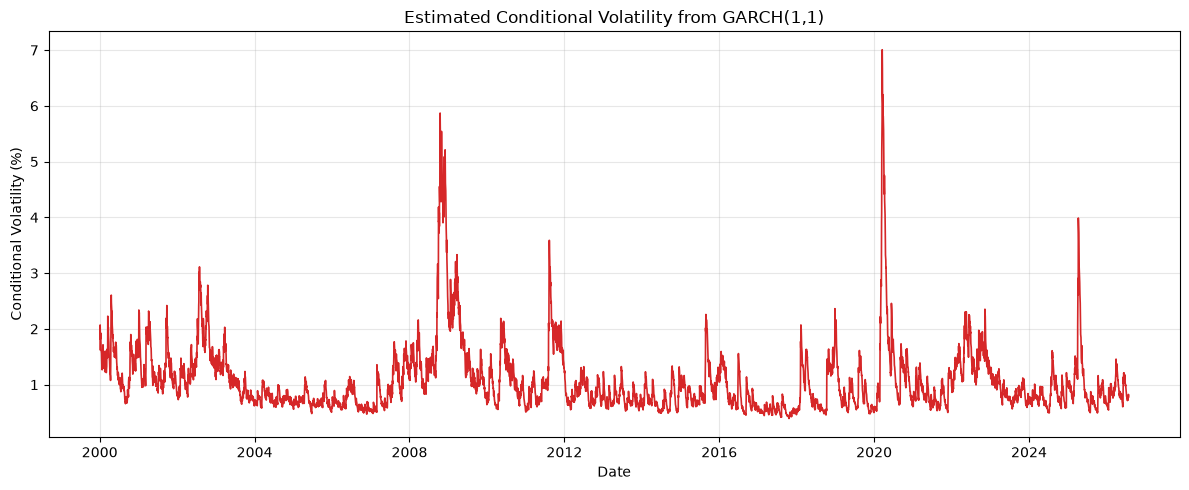

In [46]:

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    garch_output.conditional_volatility,
    color="tab:red",
    linewidth=1.2
)

ax.set_title("Estimated Conditional Volatility from GARCH(1,1)")
ax.set_xlabel("Date")
ax.set_ylabel("Conditional Volatility (%)")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Discussion